170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2466s 14us/step


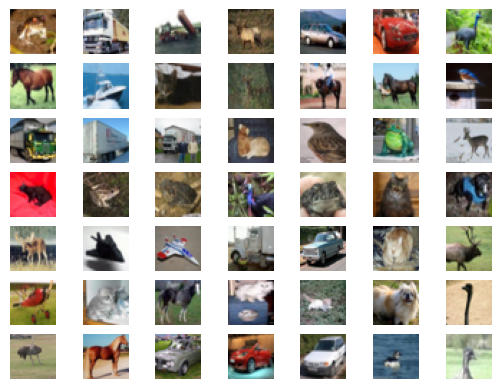

In [ ]:
from keras.datasets.cifar10 import load_data
import matplotlib.pyplot as plt
(x_train,y_train),(x_test,y_test)=load_data()

for i in range(49):
  plt.subplot(7,7,i+1)
  plt.axis("off")
  plt.imshow(x_train[i])
plt.show()

In [ ]:
print(x_train.shape)

(50000, 32, 32, 3)


### Libraries for Discriminator

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Reshape,LeakyReLU
from keras.layers import Conv2D
from keras.optimizers import Adam
from keras.utils import plot_model
import numpy as np

In [ ]:
def define_discriminator(in_shape=(32,32,3),lr=0.0002):
   model=Sequential()
   model.add(Conv2D(64,(3,3),padding='same',input_shape=in_shape))
   model.add(LeakyReLU(alpha=0.2))

   model.add(Conv2D(128,(3,3),strides=(2,2),padding='same'))
   model.add(LeakyReLU(alpha=0.2))

   model.add(Conv2D(128,(3,3),strides=(2,2),padding='same'))
   model.add(LeakyReLU(alpha=0.2))

   model.add(Conv2D(256,(3,3),strides=(2,2),padding='same'))
   model.add(LeakyReLU(alpha=0.2))

   model.add(Flatten())
   model.add(Dropout(0.4))
   model.add(Dense(1,activation='sigmoid'))

   opt=Adam(learning_rate=lr,beta_1=0.5)
   model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])
   return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

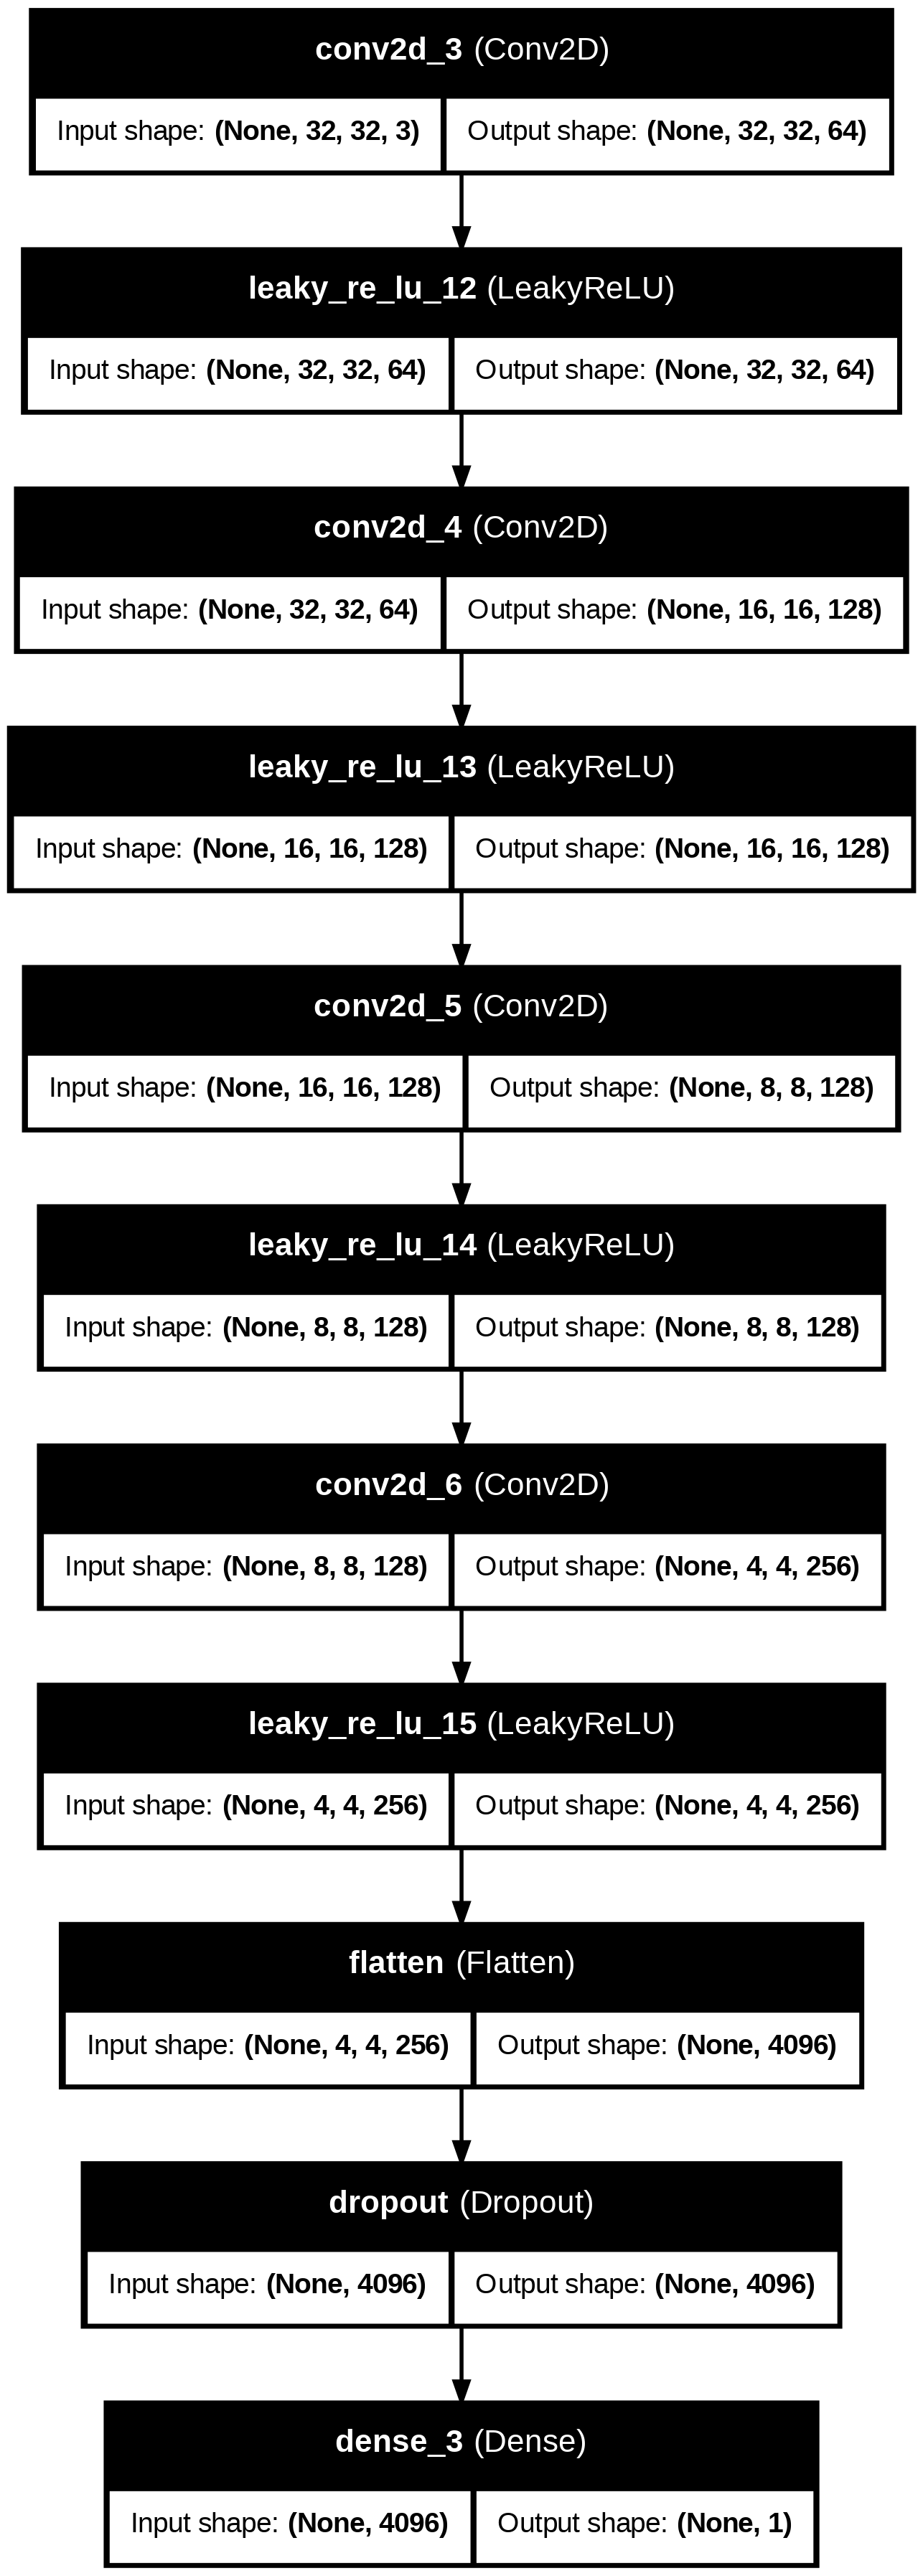

In [ ]:
model=define_discriminator()
model.summary()
plot_model(model,to_file='discriminator_plot.png',show_shapes=True,show_layer_names=True)

In [ ]:
def load_real_samples():
  (x_train,_),(_,_)=load_data()
  x=x_train.astype('float32')
  x=(x-127.5)/127.5
  return x_train

In [ ]:
X=load_real_samples()
print(X.shape)

(50000, 32, 32, 3)


In [ ]:
def generate_real_samples(dataset,n_samples):
  ix=np.random.randint(0,dataset.shape[0],n_samples)
  X=dataset[ix]
  y=np.ones((n_samples,1))
  return X,y

In [ ]:
X,y=generate_real_samples(X,64)
print(X.shape,y.shape)
print(y)

(64, 32, 32, 3) (64, 1)
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [ ]:
def generate_fake_samples(n_samples):
  X=np.random.rand(n_samples * 32 * 32 * 3)
  X=-1+X*2
  X=X.reshape(n_samples,32,32,3)
  y=np.zeros((n_samples,1))
  return X,y

In [ ]:
X,y=generate_fake_samples(64)
print(X.shape,y.shape)
print(y)

(64, 32, 32, 3) (64, 1)
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


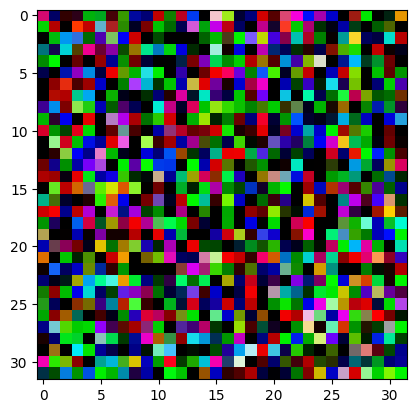

In [ ]:
plt.imshow(X[0])
plt.show()

In [ ]:
def  train_discriminator(model,dataset,n_iter=20,n_batch=128):
  half_batch=int(n_batch/2)
  for i in range(n_iter):
    X_real,Y_real=generate_real_samples(dataset,half_batch)
    _,real_acc=model.train_on_batch(X_real,Y_real)

    X_fake,Y_fake=generate_fake_samples(half_batch)
    _,fake_acc=model.train_on_batch(X_fake,Y_fake)

    print('>%d real=%0.0f%% fake=%0.0f%%'%(i+1,real_acc*100,fake_acc*100))


In [ ]:
model=define_discriminator()
dataset=load_real_samples()
train_discriminator(model,dataset)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


>1 real=36% fake=21%
>2 real=47% fake=36%
>3 real=49% fake=42%
>4 real=50% fake=45%
>5 real=51% fake=46%
>6 real=51% fake=48%
>7 real=52% fake=49%
>8 real=53% fake=51%
>9 real=54% fake=54%
>10 real=56% fake=57%
>11 real=59% fake=60%
>12 real=62% fake=63%
>13 real=64% fake=66%
>14 real=67% fake=68%
>15 real=69% fake=70%
>16 real=71% fake=72%
>17 real=73% fake=74%
>18 real=74% fake=75%
>19 real=76% fake=76%
>20 real=77% fake=78%


### Generator Part

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Reshape,LeakyReLU
from keras.layers import Conv2D,Conv2DTranspose
from keras.utils import plot_model


In [ ]:
def define_generator(latent_dim):
  model=Sequential()
  n_nodes=256*4*4
  model.add(Dense(n_nodes,input_dim=latent_dim))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Reshape((4,4,256)))

  model.add(Conv2DTranspose(128,(4,4),strides=(2,2),padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2DTranspose(128,(4,4),strides=(2,2),padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2DTranspose(128,(4,4),strides=(2,2),padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  model.add(Conv2D(3,(3,3),activation='tanh',padding='same'))
  return model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_40 (LeakyReLU)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_41 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_42 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_43 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

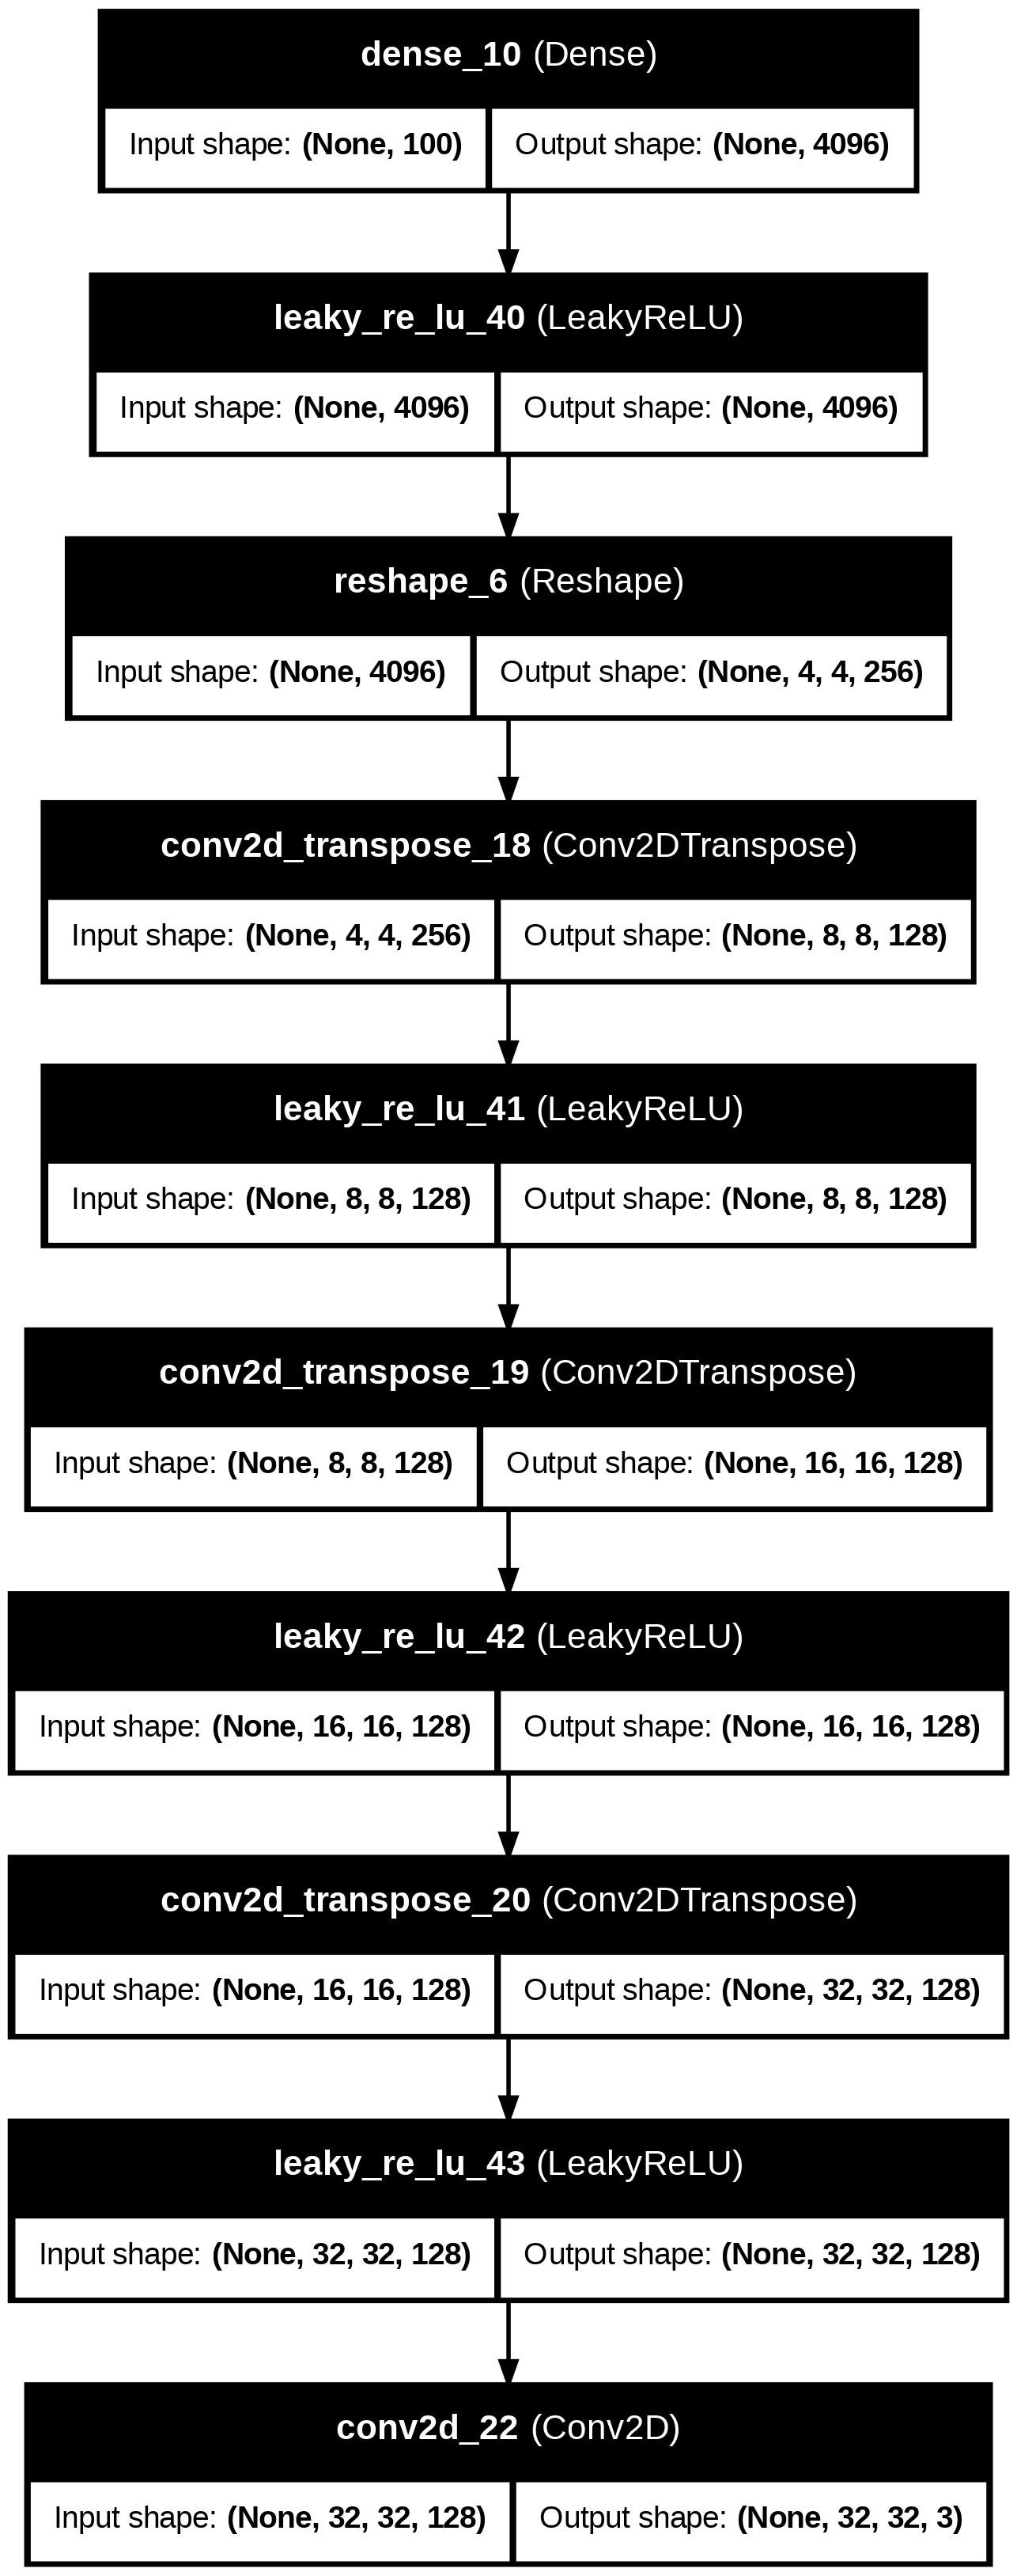

In [ ]:
latent_dim=100
model=define_generator(latent_dim)
model.summary()
plot_model(model,to_file='generator_plot.png',show_shapes=True,show_layer_names=True)

In [ ]:
def generate_latent_points(latent_dim,n_samples):
  x_input=np.random.rand(latent_dim*n_samples)
  x_input=x_input.reshape(n_samples,latent_dim)
  return x_input


In [ ]:
x_input=generate_latent_points(100,64)
print(x_input.shape)


(64, 100)


In [ ]:
def generate_fake_samples(g_model,latent_dim,n_samples):
  x_input=generate_latent_points(latent_dim,n_samples)
  X=g_model.predict(x_input)
  y=np.zeros((n_samples,1))
  return X,y

In [ ]:
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step


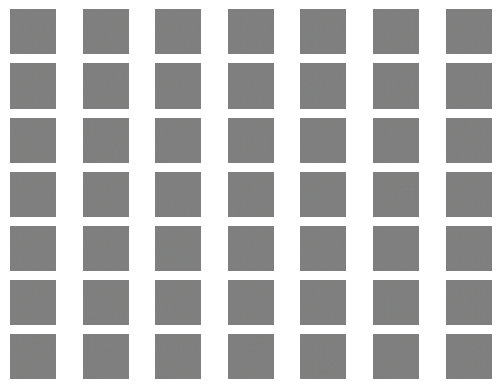

In [ ]:
latent_dim=100
model=define_generator(latent_dim)
n_samples=49
X,_=generate_fake_samples(model,latent_dim,n_samples)
X=(X+1)/2.0
for i in range(n_samples):
  plt.subplot(7,7,i+1)
  plt.axis("off")
  plt.imshow(X[i])
plt.show()


In [ ]:
def define_gan(g_model,d_model):
  d_model.trainable=False
  model=Sequential()
  model.add(g_model)
  model.add(d_model)
  opt=Adam(learning_rate=0.0002,beta_1=0.5)
  model.compile(loss='binary_crossentropy',optimizer=opt)
  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 522,497 (1.99 MB)

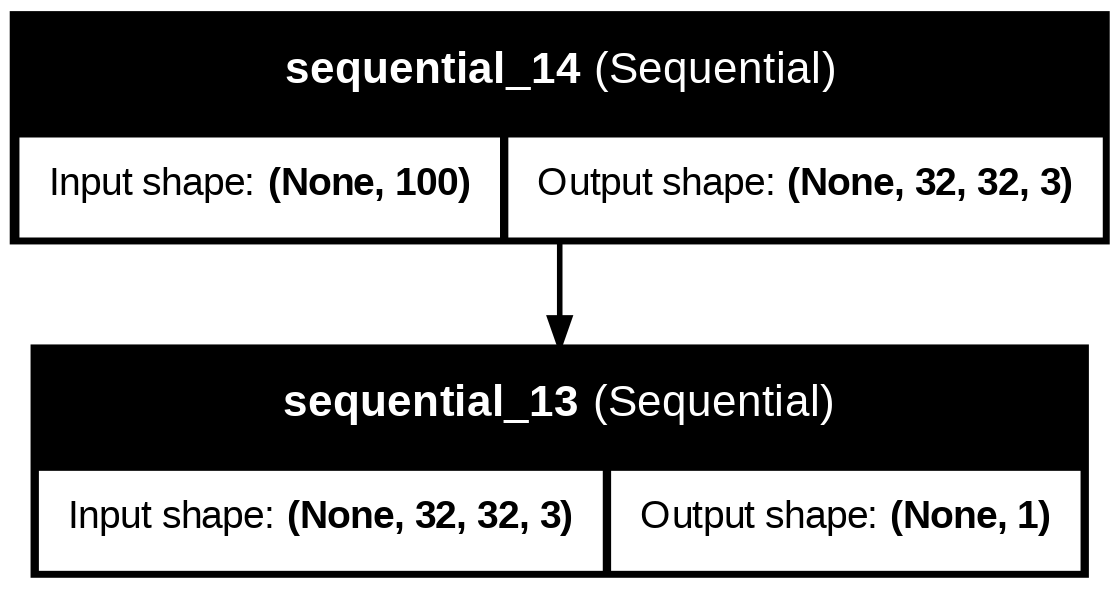

In [ ]:
latent_dim=100
d_model=define_discriminator()
g_model=define_generator(latent_dim)
gan_model=define_gan(g_model,d_model)
gan_model.summary()
plot_model(gan_model,to_file='gan_plot.png',show_shapes=True,show_layer_names=True)

In [ ]:
def train(g_model,d_model,gan_model,dataset,latent_dim,n_epochs=20,n_batch=128):
  bat_per_epo=int(dataset.shape[0]/n_batch)
  half_batch=int(n_batch/2)
  for i in range(n_epochs):
    for j in range(bat_per_epo):
      X_real,Y_real=generate_real_samples(dataset,half_batch)
      d_loss1,_=d_model.train_on_batch(X_real,Y_real)
      X_fake,Y_fake=generate_fake_samples(g_model,latent_dim,half_batch)
      d_loss2,_=d_model.train_on_batch(X_fake,Y_fake)
      X_gan=generate_latent_points(latent_dim,n_batch)
      y_gan=np.ones((n_batch,1))
      g_loss=gan_model.train_on_batch(X_gan,y_gan)
      print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f'%(i+1,j+1,bat_per_epo,d_loss1,d_loss2,g_loss))
    if (i+1)%10==0:
      summarize_performance(i,g_model,d_model,dataset,latent_dim)

In [ ]:
def summarize_performance(epoch,g_model,d_model,dataset,latent_dim,n_samples=150):
  X_real,y_real=generate_real_samples(dataset,n_samples)
  _,acc_real=d_model.evaluate(X_real,y_real,verbose=0)
  x_fake,y_fake=generate_fake_samples(g_model,latent_dim,n_samples)
  _,acc_fake=d_model.evaluate(x_fake,y_fake,verbose=0)
  print('>Accuracy real=%.0f%%,fake=%.0f%%'%(acc_real*100,acc_fake*100))
  save_plot(x_fake,epoch)
  filename='generator_model_%03d.h5'%(epoch+1)
  g_model.save(filename)

In [ ]:
def save_plot(examples,epoch,n=7):
  examples=(examples+1)/2.0
  for i in range(n*n):
    plt.subplot(n,n,i+1)
    plt.axis('off')
    plt.imshow(examples[i])
  filename='generated_plot_e%03d.png'%(epoch+1)
  plt.savefig(filename)
  plt.close()

In [ ]:
train(g_model,d_model,gan_model,dataset,latent_dim,n_epochs=20,n_batch=128)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 
>1, 1/390, d1=0.221, d2=0.457 g=0.693
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
>1, 2/390, d1=0.453, d2=0.513 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
>1, 3/390, d1=0.433, d2=0.477 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
>1, 4/390, d1=0.449, d2=0.480 g=0.691
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
>1, 5/390, d1=0.445, d2=0.471 g=0.690
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
>1, 6/390, d1=0.457, d2=0.478 g=0.688
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
>1, 7/390, d1=0.473, d2=0.490 g=0.687
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
>1, 8/390, d1=0.470, d2=0.486 g=0.684
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
>1, 9/390, d1=0.483, d2=0.497 g=0.681
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
>1, 10/390, d1=0.485, d2=0.498 g=0.677
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
>1, 11/390, d1=0.492, d2=0.505 g=0.672
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
>1, 12/390, d1=0.516, d2=0.528 g=0.666
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
>1, 13/390, d1=0.523, d2=0.534 g=0.659
2/2 ━━━